# Imports and dataloading

In [1]:
from lineagetree import read_from_mastodon
import numpy as np
import matplotlib.pyplot as plt
import h5py

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

import importlib

In [ ]:
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 500 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

In [3]:
# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # for no downscaling (0-th level of the hdf5), (as measured in T7_3 data (dir = H:))
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]


# Crop watershed

In [24]:
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion

im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

In [5]:
# CREATE AN IMAGE AROUND A GIVEN SEED
def crop_around_seed(image_:np.ndarray, seed_label_:int, radius_:int)->np.ndarray:
    """Create a boxed crop of an image, centered around an annotation seed for a 

    Args:
        image_ (np.ndarray): Image to be croped
        seed_label_ (int): Label of the seed to be in the center of the crop
        radius_ (int): 1/2 -1 the size of the crop in each direction 

    Returns:
        np.ndarray: cropped image around the seed. 
    """    

    sp = seeds_pos[seed_label_]

    z_min = max(sp[0]-radius_, 0)
    y_min = max(sp[1]-radius_, 0)
    x_min = max(sp[2]-radius_, 0)

    z_max = min(sp[0]+radius_+1, image_.shape[0])
    y_max = min(sp[1]+radius_+1, image_.shape[1])
    x_max = min(sp[2]+radius_+1, image_.shape[2])

    return image_[z_min:z_max, y_min:y_max, x_min:x_max]


from skimage.segmentation import watershed

# DO AN ADAPTIVE WS SEGMENTATION AROUND A GIVEN CROPPED IMAGE
def small_adatpive_ws(
        croped_image,
        croped_seed_array,
        thresholds_list,
        label_,
        min_vol = 70,
        max_vol = 1500
):
    
    for i, thresh in enumerate(thresholds_list):
        mask = croped_image > thresh
        small_ws = watershed(croped_image, croped_seed_array, mask=mask)

        vols = {}
        labels, volumes = np.unique_counts(small_ws) # labels are consistent!
        vols = dict(zip(labels, volumes))

        if label_ in small_ws: # NEEDS A CASE FOR I=0
            # print('ok')
            # print(f'volume = {vols[label_]}')
            if min_vol < vols[label_] < max_vol:
                # found_int[label_] = [thresholds_list[i], thresholds_list[i-1]]
                print(f'found threshold = {thresh}, vol = {vols[label_]}')
                return small_ws, mask

    
    return np.zeros_like(small_ws), mask


def update_image(empty_watershed, small_image, seeds_pos, label_):
    big_mask = empty_watershed < -1 # This is False everywhere

    sp = seeds_pos[label_]
    small_rad = int((small_image.shape[0]-1)/2)

    z_min = max(sp[0]-small_rad, 0)
    y_min = max(sp[1]-small_rad, 0)
    x_min = max(sp[2]-small_rad, 0)

    z_max = min(sp[0]+small_rad+1, empty_watershed.shape[0])
    y_max = min(sp[1]+small_rad+1, empty_watershed.shape[1])
    x_max = min(sp[2]+small_rad+1, empty_watershed.shape[2])

    small_mask = small_image == label_
    big_mask[z_min: z_max, y_min:y_max, x_min:x_max]=small_mask

    empty_watershed[big_mask] = label_

    return empty_watershed

In [25]:
MAX_VOL = 1500

MAX_RAD = int(2*(3*MAX_VOL/(4*np.pi))**(1/3))
print(MAX_RAD)
imageaki = crop_around_seed(im_for_ws, 292, MAX_RAD)
araki = crop_around_seed(seeds_array, 292, MAX_RAD)

14


In [ ]:
def small_adatpive_ws_steps_results(
        croped_image,
        croped_seed_array,
        thresholds_list,
        label_,
        min_vol = 70,
        max_vol = 1500
):
    
    results_dict = {}
    results_dict['masks'] = {}
    results_dict['segm'] = {}

    for i, thresh in enumerate(thresholds_list):
        mask = croped_image > thresh
        small_ws = watershed(croped_image, croped_seed_array, mask=mask)

        vols = {}
        labels, volumes = np.unique_counts(small_ws) # labels are consistent!
        vols = dict(zip(labels, volumes))

        if label_ in small_ws: # NEEDS A CASE FOR I=0
            # print('ok')
            # print(f'volume = {vols[label_]}')
            if min_vol < vols[label_] < max_vol:
                # found_int[label_] = [thresholds_list[i], thresholds_list[i-1]]
                print(f'found threshold = {thresh}, vol = {vols[label_]}')
    
        results_dict['masks'][thresh]=mask
        results_dict['segm'][thresh]=small_ws
    
    return results_dict

In [26]:
results ={}
results = small_adatpive_ws_steps_results(imageaki, araki, range(1, 160)[::-1], 292)

found threshold = 113, vol = 113
found threshold = 112, vol = 123
found threshold = 111, vol = 131
found threshold = 110, vol = 143
found threshold = 109, vol = 160
found threshold = 108, vol = 167
found threshold = 107, vol = 184
found threshold = 106, vol = 200
found threshold = 105, vol = 210
found threshold = 104, vol = 228
found threshold = 103, vol = 239
found threshold = 102, vol = 251
found threshold = 101, vol = 275
found threshold = 100, vol = 287
found threshold = 99, vol = 303
found threshold = 98, vol = 316
found threshold = 97, vol = 334
found threshold = 96, vol = 353
found threshold = 95, vol = 370


In [30]:
import napari

viewer = napari.Viewer()

viewer.add_image(imageaki)
viewer.add_image(araki)
for i in range(95, 125)[::-3]:
    viewer.add_labels(results['segm'][i], name=f'SEG : {i}')
    viewer.add_labels(results['masks'][i], name=f'MASK : {i}')
napari.run()

In [47]:
im_for_ws = main.preprocess_im(raw_image)

In [19]:
imageaki = crop_around_seed(im_for_ws, 501, MAX_RAD)


results = small_adatpive_ws_steps_results(imageaki, araki, range(1, 160)[::-2], 501)

found threshold = 13, vol = 1357
found threshold = 11, vol = 1368
found threshold = 9, vol = 512


In [43]:
viewer = napari.Viewer()

viewer.add_image(imageaki)
viewer.add_image(araki)
for i in range(151, 156)[::-2]:
    viewer.add_labels(results['segm'][i], name=f'SEG : {i}')
    viewer.add_labels(results['masks'][i], name=f'MASK : {i}')
napari.run()

# Masks bound by spheres

## Test Functions

In [4]:
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion

im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

In [22]:
 # CREATE AN IMAGE AROUND A GIVEN SEED
def crop_around_seed(image_:np.ndarray, seed_label_:int, radius_:int)->np.ndarray:
    """Create a boxed crop of an image, centered around an annotation seed for a 

    Args:
        image_ (np.ndarray): Image to be croped
        seed_label_ (int): Label of the seed to be in the center of the crop
        radius_ (int): 1/2 -1 the size of the crop in each direction 

    Returns:
        np.ndarray: cropped image around the seed. 
    """    

    sp = seeds_pos[seed_label_]

    z_min = max(sp[0]-radius_, 0)
    y_min = max(sp[1]-radius_, 0)
    x_min = max(sp[2]-radius_, 0)

    z_max = min(sp[0]+radius_+1, image_.shape[0])
    y_max = min(sp[1]+radius_+1, image_.shape[1])
    x_max = min(sp[2]+radius_+1, image_.shape[2])

    return image_[z_min:z_max, y_min:y_max, x_min:x_max]

def sphere_mask(array_shape: tuple, center: tuple, radius: float) -> np.ndarray:
    """
    Creates a boolean mask where True indicates a point is inside a sphere.
    
    Parameters:
        array_shape : Shape of the output mask (e.g., (D, H, W) for 3D)
        center      : Center of the sphere (e.g., (z0, y0, x0))
        radius      : Radius of the sphere
    
    Returns:
        Boolean NumPy array of the given shape
    """
    # Build a grid of indices for each dimension
    grids = np.ogrid[tuple(slice(0, s) for s in array_shape)]
    
    # Sum squared distances along each dimension
    dist_sq = sum(
        (grid - c) ** 2
        for grid, c in zip(grids, center)
    )
    
    return dist_sq <= radius ** 2


def update_image(empty_watershed, small_image, seeds_pos, label_):
    big_mask = empty_watershed < -1 # This is False everywhere

    sp = seeds_pos[label_]
    small_rad = int((small_image.shape[0]-1)/2)

    z_min = max(sp[0]-small_rad, 0)
    y_min = max(sp[1]-small_rad, 0)
    x_min = max(sp[2]-small_rad, 0)

    z_max = min(sp[0]+small_rad+1, empty_watershed.shape[0])
    y_max = min(sp[1]+small_rad+1, empty_watershed.shape[1])
    x_max = min(sp[2]+small_rad+1, empty_watershed.shape[2])

    small_mask = small_image == label_
    big_mask[z_min: z_max, y_min:y_max, x_min:x_max]=small_mask

    empty_watershed[big_mask] = label_

    return empty_watershed

In [6]:
MAX_VOL = 1500
MAX_RAD = int(2*(3*MAX_VOL/(4*np.pi))**(1/3))

MIN_VOL = 70
MIN_RAD = int((3*MIN_VOL/(4*np.pi))**(1/3))

### label = 292

In [43]:
imageaki = crop_around_seed(im_for_ws, 292, MAX_RAD)
araki = crop_around_seed(seeds_array, 292, MAX_RAD)

False


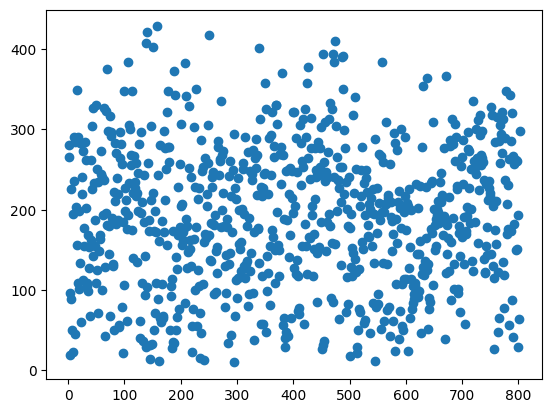

In [44]:
from scipy.spatial.distance import cdist

distance_pairs = cdist([seeds_pos[292]], [seeds_pos[i] for i in set(seeds_pos.keys())-{292}], metric='euclidean') # distances between all OTHER labels
# Question, why are elements float?

print(0 in distance_pairs) # test does not include the 0 distance (distance to self) 
plt.scatter([i for i in set(seeds_pos.keys())-{292}], distance_pairs)

In [ ]:
np.min(im)

In [ ]:
import napari 

viewer = napari.Viewer()
viewer.add_image(imageaki)
viewer.add_image(araki)
napari.run()

In [ ]:
# find the positions of annotations in the cropped image
with utils.block_timer():
    for i in range(5000):
        np.where(araki==292)

[item for row in np.where(araki==292) for item in row]

-(Time elapsed: 0.746304 s)


[np.int64(14), np.int64(14), np.int64(14)]

using np.where takes about a second per timepoint... See if you want to just calculate the positions. Make sure not to recalculate it for each treshold. 

In [ ]:
labbb, _ = np.unique_counts(araki)
geometry_mask = araki<0
for lab in labbb:
   geometry_mask = geometry_mask | sphere_mask(araki.shape, [item for row in np.where(araki==lab) for item in row], 5)

In [ ]:
intensity_mask = imageaki > 100
combine_masks = geometry_mask & intensity_mask

In [ ]:
from skimage.segmentation import watershed

test_watersh = watershed(imageaki, araki, mask=combine_masks)

In [ ]:
import napari 

viewer = napari.Viewer()
viewer.add_image(imageaki)
viewer.add_image(araki)
viewer.add_labels(geometry_mask)
viewer.add_labels(intensity_mask)
viewer.add_labels(combine_masks)
viewer.add_labels(test_watersh)

napari.run()

### label = 501 

In [ ]:
imageaki = crop_around_seed(im_for_ws, 501, MAX_RAD)
araki = crop_around_seed(seeds_array, 501, MAX_RAD)

In [ ]:
from scipy.spatial.distance import cdist
from math import floor

distance_pairs = cdist([seeds_pos[501]], [seeds_pos[i] for i in set(seeds_pos.keys())-{501}], metric='euclidean') # distances between all OTHER labels
SHP_RAD = floor(np.min(distance_pairs)/2)
print(f'minimum distance = {np.min(distance_pairs)}, shpere radius = {SHP_RAD}')

minimum distance = 8.660254037844387, shpere radius = 4


In [ ]:
labbb, _ = np.unique_counts(araki)
geometry_mask = araki<0
for lab in labbb:
   geometry_mask = geometry_mask | sphere_mask(araki.shape, [item for row in np.where(araki==lab) for item in row], SHP_RAD)

intensity_mask = imageaki > 100
combine_masks = geometry_mask & intensity_mask

test_watersh = watershed(imageaki, araki, mask=combine_masks)

In [ ]:
import napari 

viewer = napari.Viewer()
viewer.add_image(imageaki)
viewer.add_image(araki)
viewer.add_labels(geometry_mask)
viewer.add_labels(intensity_mask)
viewer.add_labels(combine_masks)
viewer.add_labels(test_watersh)

napari.run()

## Apply to the whole image

In [23]:
 # CREATE AN IMAGE AROUND A GIVEN SEED
def crop_around_seed(image_:np.ndarray, seed_label_:int, radius_:int)->np.ndarray:
    """Create a boxed crop of an image, centered around an annotation seed for a 

    Args:
        image_ (np.ndarray): Image to be croped
        seed_label_ (int): Label of the seed to be in the center of the crop
        radius_ (int): 1/2 -1 the size of the crop in each direction 

    Returns:
        np.ndarray: cropped image around the seed. 
    """    

    sp = seeds_pos[seed_label_]

    z_min = max(sp[0]-radius_, 0)
    y_min = max(sp[1]-radius_, 0)
    x_min = max(sp[2]-radius_, 0)

    z_max = min(sp[0]+radius_+1, image_.shape[0])
    y_max = min(sp[1]+radius_+1, image_.shape[1])
    x_max = min(sp[2]+radius_+1, image_.shape[2])

    return image_[z_min:z_max, y_min:y_max, x_min:x_max]

def sphere_mask(array_shape: tuple, center: tuple, radius: float) -> np.ndarray:
    """_summary_

    Args:
        array_shape (tuple): _description_
        center (tuple): _description_
        radius (float): _description_

    Returns:
        np.ndarray: _description_
    """
    # Build a grid of indices for each dimension
    grids = np.ogrid[tuple(slice(0, s) for s in array_shape)]
    
    # Sum squared distances along each dimension
    dist_sq = sum( (grid - c) ** 2
        for grid, c in zip(grids, center)
    )
    
    return dist_sq <= radius ** 2


def update_image(empty_watershed, small_image, seeds_pos, label_):
    """Update only a given label value in a large image from a smaller image

    Args:
        empty_watershed (_type_): _description_
        small_image (_type_): _description_
        seeds_pos (_type_): _description_
        label_ (_type_): _description_

    Returns:
        _type_: _description_
    """    
    big_mask = empty_watershed < -1 # This is False everywhere

    sp = seeds_pos[label_]
    small_rad = int((small_image.shape[0]-1)/2)

    z_min = max(sp[0]-small_rad, 0)
    y_min = max(sp[1]-small_rad, 0)
    x_min = max(sp[2]-small_rad, 0)

    z_max = min(sp[0]+small_rad+1, empty_watershed.shape[0])
    y_max = min(sp[1]+small_rad+1, empty_watershed.shape[1])
    x_max = min(sp[2]+small_rad+1, empty_watershed.shape[2])

    small_mask = small_image == label_
    big_mask[z_min: z_max, y_min:y_max, x_min:x_max]=small_mask

    empty_watershed[big_mask] = label_

    return empty_watershed

In [8]:
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion

im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

In [ ]:
MAX_VOL = 1500
MAX_RAD = int(2*(3*MAX_VOL/(4*np.pi))**(1/3))

MIN_VOL = 70
MIN_RAD = int((3*MIN_VOL/(4*np.pi))**(1/3))

In [24]:
from math import floor, ceil
from tqdm import tqdm
from scipy.spatial.distance import cdist
from skimage.segmentation import watershed

updated_watershed = np.zeros_like(im_for_ws)
all_seeds = set(np.unique(seeds_array)) - {0} # don't include the background

for label in tqdm(all_seeds, desc='label = '):
# for label in tqdm([271], desc='label = '): # check the results of a specific label
   crop_image = crop_around_seed(im_for_ws, label, MAX_RAD)
   crop_array = crop_around_seed(seeds_array, label, MAX_RAD)
   small_watershed = np.zeros_like(crop_image)

   labels_in_crop_array = set(np.unique(crop_array)) - {0}

   if len(labels_in_crop_array) <= 1:
      geometry_mask = ~(crop_image < 0)
      
   else:
      distance_pairs = cdist([seeds_pos[label]], [seeds_pos[i] for i in (labels_in_crop_array-{label})], metric='euclidean') # distances between all OTHER labels in crop
      # SHP_RAD = floor(np.min(distance_pairs)/2) - 1
      SHP_RAD = ceil(np.min(distance_pairs)/2) - 1

      geometry_mask = crop_array<0 # is 0 everywhere initialy.

      for lab in labels_in_crop_array:
         geometry_mask = geometry_mask | sphere_mask(crop_array.shape, [item for row in np.where(crop_array==lab) for item in row], SHP_RAD)

   for threshold in range(0,160)[::-1]:

      intensity_mask = crop_image > threshold
      combine_masks = geometry_mask & intensity_mask
      small_watershed = watershed(crop_image, crop_array, mask=combine_masks)

      vols = {}
      labels, volumes = np.unique_counts(small_watershed)
      vols = dict(zip(labels, volumes))

      if label in small_watershed and (MIN_VOL < vols[label] < MAX_VOL):
         update_image(updated_watershed, small_watershed, seeds_pos, label) # update only the label in interation.
         break

label = :  44%|████▍     | 351/802 [00:53<01:03,  7.08it/s]C:\Users\Tassos\AppData\Local\Temp\ipykernel_19620\2886523630.py:16: RuntimeWarning: overflow encountered in scalar subtract
  z_min = max(sp[0]-radius_, 0)
label = : 100%|██████████| 802/802 [02:04<00:00,  6.46it/s]


In [ ]:
vols[630]

In [37]:
import napari

viewer = napari.Viewer()
viewer.add_image(crop_image)
viewer.add_labels(crop_array)
viewer.add_labels(intensity_mask)
viewer.add_labels(small_watershed)

napari.run()

In [25]:
import napari
viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_labels(seeds_array)
viewer.add_labels(updated_watershed)

napari.run()

# Use the median lines

#### cdist functions playground

##### 2D arrays

In [ ]:
test_img1 = np.zeros([20,20])
padd = test_img1 == 0
test_img1[padd] = 1
test_img1[14,2] = 0

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(test_img1)

In [ ]:
from scipy.ndimage import distance_transform_edt as dte

dist_1 = dte(test_img1)
plt.imshow(dist_1)

In [ ]:
test_img2 = np.zeros([20,20])
padd = test_img2 == 0
test_img2[padd] = 1
test_img2[10,15] = 0

dist_2 = dte(test_img2)

In [ ]:
view = napari.Viewer()
view.add_image(dist_1)
view.add_image(dist_2)

In [ ]:
mask = np.abs(dist_1 - dist_2) < 1

In [ ]:
view = napari.Viewer()
view.add_image(dist_1)
view.add_image(dist_2)
view.add_labels(mask)

##### 3D arrays

In [ ]:
import numpy as np
from scipy.ndimage import distance_transform_edt as dte

p1 = np.asarray([int(i) for i in 20*np.random.random(3)])
p2 = np.asarray([int(i) for i in 20*np.random.random(3)])
print(p1, p2)

test_img1 = np.zeros([20,20,20])
padd = test_img1 == 0
test_img1[padd] = 1
test_img1[tuple(p1.T)] = 0
dist_1 = dte(test_img1)

test_img2 = np.zeros([20,20,20])
padd = test_img2 == 0
test_img2[padd] = 1
test_img2[tuple(p2.T)] = 0
dist_2 = dte(test_img2)

mask = np.abs(dist_1 - dist_2) < 1

In [ ]:
list(map(int, 20*np.random.random(3)))

In [ ]:
import napari

view = napari.Viewer()
view.add_image(dist_1)
view.add_image(test_img1)
view.add_image(test_img2)
view.add_image(dist_2)
view.add_labels(mask)

## Loop over the whole image / test for a single label

In [56]:
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion

im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

In [ ]:
# CROP THE IMAGE AROUND A GIVEN SEED
def crop_around_seed(image_:np.ndarray, seed_label_:int, radius_:int)->np.ndarray:
    """Create a boxed crop of an image, centered around an annotation seed for a 

    Args:
        image_ (np.ndarray): Image to be croped
        seed_label_ (int): Label of the seed to be in the center of the crop
        radius_ (int): 1/2 -1 the size of the crop in each direction 

    Returns:
        np.ndarray: cropped image around the seed. 
    """    

    sp = seeds_pos[seed_label_]

    z_min = max(sp[0]-radius_, 0)
    y_min = max(sp[1]-radius_, 0)
    x_min = max(sp[2]-radius_, 0)

    z_max = min(sp[0]+radius_+1, image_.shape[0])
    y_max = min(sp[1]+radius_+1, image_.shape[1])
    x_max = min(sp[2]+radius_+1, image_.shape[2])

    return image_[z_min:z_max, y_min:y_max, x_min:x_max]


def update_image(empty_watershed, small_image, seeds_pos, label_):
    big_mask = empty_watershed < -1 # This is False everywhere

    sp = seeds_pos[label_]
    small_rad = int((small_image.shape[0]-1)/2)

    z_min = max(sp[0]-small_rad, 0)
    y_min = max(sp[1]-small_rad, 0)
    x_min = max(sp[2]-small_rad, 0)

    z_max = min(sp[0]+small_rad+1, empty_watershed.shape[0])
    y_max = min(sp[1]+small_rad+1, empty_watershed.shape[1])
    x_max = min(sp[2]+small_rad+1, empty_watershed.shape[2])

    small_mask = small_image == label_
    big_mask[z_min: z_max, y_min:y_max, x_min:x_max]=small_mask

    empty_watershed[big_mask] = label_

    return empty_watershed

In [54]:
seeds_pos[501]

array([214, 263,  57], dtype=uint16)

In [15]:
from scipy.ndimage import distance_transform_edt as dte

def find_median_plane(point_1_position, point_2_position, image_shape):
    dist_arr_1 = np.zeros(image_shape)
    pad = dist_arr_1 == 0
    dist_arr_1[pad] = 1
    dist_arr_1[tuple(point_1_position.T)] = 0
    dist_arr_1 = dte(dist_arr_1)

    dist_arr_2 = np.zeros(image_shape)
    pad = dist_arr_2 == 0
    dist_arr_2[pad] = 1
    dist_arr_2[tuple(point_2_position.T)] = 0
    dist_arr_2 = dte(dist_arr_2)

    median_plane_mask = np.abs(dist_arr_2 - dist_arr_1) < 1

    return median_plane_mask

In [32]:
MAX_VOL = 1000
MAX_RAD = int(2*(3*MAX_VOL/(4*np.pi))**(1/3))

MIN_VOL = 300
MIN_RAD = int((3*MIN_VOL/(4*np.pi))**(1/3))

In [33]:
from math import floor, ceil
from tqdm import tqdm
from scipy.spatial.distance import cdist
from skimage.segmentation import watershed

updated_watershed = np.zeros_like(im_for_ws)
all_seeds = set(np.unique(seeds_array)) - {0} # don't include the background

for label in tqdm(all_seeds, desc='label = '):
# for label in tqdm([501], desc='label = '): # check the results of a specific label
   crop_image = crop_around_seed(im_for_ws, label, MAX_RAD)
   crop_array = crop_around_seed(seeds_array, label, MAX_RAD)
   small_watershed = np.zeros_like(crop_image)

   labels_in_crop_array = set(np.unique(crop_array)) - {0}
   center_pos = [item for row in np.where(crop_array==label) for item in row]

   if len(labels_in_crop_array) <= 1: # if the annotation is the only in the cropped array
      geometry_mask = ~(crop_image < 0)
      
   else:
    geometry_mask = crop_array <0 # 0 everywhere

    for other_label in labels_in_crop_array - {label}: # all OTHER labels
      ann_pos = [item for row in np.where(crop_array==other_label) for item in row]
      med_plane = find_median_plane(np.asarray(center_pos), np.asarray(ann_pos), crop_array.shape)
      geometry_mask = geometry_mask | med_plane # add a median plane for echa annotation in crop_array

   for threshold in range(10,160)[::-5]:

      intensity_mask = crop_image > threshold
      combine_masks = intensity_mask & ~geometry_mask
      small_watershed = watershed(crop_image, crop_array, mask=combine_masks)

      vols = {}
      labels, volumes = np.unique_counts(small_watershed)
      vols = dict(zip(labels, volumes))

      if label in small_watershed and (MIN_VOL < vols[label] < MAX_VOL):
         update_image(updated_watershed, small_watershed, seeds_pos, label) # update only the label in interation.
         break

label = :  44%|████▍     | 351/802 [00:24<00:29, 15.18it/s]C:\Users\Tassos\AppData\Local\Temp\ipykernel_19620\2886523630.py:16: RuntimeWarning: overflow encountered in scalar subtract
  z_min = max(sp[0]-radius_, 0)
label = : 100%|██████████| 802/802 [00:55<00:00, 14.53it/s]


In [72]:
import napari

view = napari.Viewer()
view.add_image(crop_image)
view.add_labels(crop_array)
view.add_labels(geometry_mask)
view.add_labels(intensity_mask)
view.add_labels(small_watershed)

<Labels layer 'small_watershed' at 0x29e07d44a60>

In [34]:
view = napari.Viewer()
view.add_image(im_for_ws)
view.add_labels(seeds_array)
view.add_labels(updated_watershed)

<Labels layer 'updated_watershed' at 0x1bb3f93f340>

##